# Advanced Models: Random Forest and XGBoost

Pipeline:
1. Load train/test splits from feature selection stage
2. Tune Random Forest via GridSearchCV with 5-Fold CV
3. Tune XGBoost via GridSearchCV with 5-Fold CV
4. Evaluate and compare both models

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Load Data

In [2]:
DATA_DIR = Path("..") / "data" / "final2"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").values.ravel()
y_test  = pd.read_csv(DATA_DIR / "y_test.csv").values.ravel()

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")

X_train : (2231, 24)  |  X_test : (558, 24)
y_train : (2231,)  |  y_test : (558,)


#### Helper Functions

In [3]:
def adjusted_r2(r2: float, n: int, k: int) -> float:
    """
    Compute adjusted R² score.

    Args:
        r2: Standard R² score.
        n : Number of samples.
        k : Number of features.

    Returns:
        Adjusted R² value.
    """
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


def evaluate_model(model, X_train, y_train, X_test, y_test) -> dict:
    """
    Evaluate a fitted model on train and test sets.

    Args:
        model  : Fitted sklearn-compatible regressor.
        X_train, y_train: Training features and target.
        X_test,  y_test : Test features and target.

    Returns:
        Dict with R², Adj R², RMSE, MAE for both train and test.
    """
    results = {}
    for split, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        preds = model.predict(X)
        r2    = r2_score(y, preds)
        results[split] = {
            "R²":      round(r2, 4),
            "Adj R²":  round(adjusted_r2(r2, len(y), X.shape[1]), 4),
            "RMSE":    round(np.sqrt(mean_squared_error(y, preds)), 4),
            "MAE":     round(mean_absolute_error(y, preds), 4),
        }
    return results


def feature_importance_table(model, feature_names: list, top_n: int = 10) -> pd.DataFrame:
    """
    Return top-N feature importances as a sorted DataFrame.

    Args:
        model        : Fitted model with feature_importances_ attribute.
        feature_names: List of feature column names.
        top_n        : Number of top features to return.

    Returns:
        DataFrame with Feature and Importance columns.
    """
    return (
        pd.DataFrame({"Feature": feature_names, "Importance": model.feature_importances_})
        .sort_values("Importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# Shared 5-Fold CV splitter
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Store all model results for final comparison
all_results = {}

### Random Forest — Hyperparameter Tuning

In [4]:
rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_SEED),
    param_grid=rf_param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print(f"Best parameters : {rf_grid.best_params_}")
print(f"Best CV MSE     : {-rf_grid.best_score_:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best parameters : {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV MSE     : 39999.93


In [5]:
rf_results = evaluate_model(best_rf, X_train, y_train, X_test, y_test)
all_results["Random Forest"] = rf_results

print("Random Forest — Performance")
print(pd.DataFrame(rf_results).T.to_string())

print("\nTop 10 Feature Importances")
print(feature_importance_table(best_rf, X_train.columns.tolist()).to_string(index=False))

Random Forest — Performance
           R²  Adj R²      RMSE       MAE
Train  0.6106  0.6064  176.9690  137.2620
Test   0.4642  0.4401  206.0775  160.1625

Top 10 Feature Importances
                Feature  Importance
LP_Mainfield(in Tonnes)    0.117652
         Potassh_50Days    0.117409
        Seedrate(in Kg)    0.101828
    Weed28D_thiobencarb    0.088140
  Micronutrients_70Days    0.086723
      Pest_60Day(in ml)    0.085525
             DAP_20days    0.081444
   Nursery area (Cents)    0.074222
            Urea_40Days    0.071986
    Variety_delux ponni    0.036046


#### XGBoost — Hyperparameter Tuning

In [6]:
xgb_param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7, 10],
    'learning_rate':   [0.01, 0.05, 0.1],
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_SEED, verbosity=0, n_jobs=-1),
    param_grid=xgb_param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

print(f"Best parameters : {xgb_grid.best_params_}")
print(f"Best CV MSE     : {-xgb_grid.best_score_:.2f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV MSE     : 37290.01


In [7]:
xgb_results = evaluate_model(best_xgb, X_train, y_train, X_test, y_test)
all_results["XGBoost"] = xgb_results

print("XGBoost — Performance")
print(pd.DataFrame(xgb_results).T.to_string())

print("\nTop 10 Feature Importances")
print(feature_importance_table(best_xgb, X_train.columns.tolist()).to_string(index=False))

XGBoost — Performance
           R²  Adj R²      RMSE       MAE
Train  0.5565  0.5517  188.8607  146.9933
Test   0.5119  0.4899  196.7047  152.9752

Top 10 Feature Importances
                         Feature  Importance
                      DAP_20days    0.751588
             Variety_delux ponni    0.100959
                 Variety_ponmani    0.041933
Inst Wind Speed_D1_D30(in Knots)    0.031595
                Max temp_D61_D90    0.017777
        Relative Humidity_D1_D30    0.014631
                 Soil Types_clay    0.014205
       Relative Humidity_D61_D90    0.007855
                     Nursery_wet    0.006964
                Min temp_D31_D60    0.005551


### LightGBM

In [8]:
import lightgbm as lgb

lgb_param_grid = {
    'n_estimators':   [100, 200, 300],
    'max_depth':      [3, 5, 7, -1],       
    'learning_rate':  [0.01, 0.05, 0.1],
    'num_leaves':     [15, 31, 63],        # key LightGBM param — controls complexity

}

lgb_grid = GridSearchCV(
    estimator=lgb.LGBMRegressor(random_state=RANDOM_SEED, verbose=-1),
    param_grid=lgb_param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
lgb_grid.fit(X_train, y_train)

best_lgb = lgb_grid.best_estimator_

print(f"Best parameters : {lgb_grid.best_params_}")
print(f"Best CV MSE     : {-lgb_grid.best_score_:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 15}
Best CV MSE     : 37259.39


In [9]:
lgb_results = evaluate_model(best_lgb, X_train, y_train, X_test, y_test)
all_results["LightGBM"] = lgb_results

print("LightGBM — Performance")
print(pd.DataFrame(lgb_results).T.to_string())

print("\nTop 10 Feature Importances")
print(feature_importance_table(best_lgb, X_train.columns.tolist()).to_string(index=False))

LightGBM — Performance
           R²  Adj R²      RMSE       MAE
Train  0.5572  0.5524  188.7222  146.9379
Test   0.5119  0.4899  196.6966  153.0358

Top 10 Feature Importances
                         Feature  Importance
                      DAP_20days         287
                 Soil Types_clay          80
                Max temp_D61_D90          75
             Variety_delux ponni          59
                     Nursery_wet          52
                 Variety_ponmani          50
                 Max temp_D1_D30          35
        Relative Humidity_D1_D30          26
Inst Wind Speed_D1_D30(in Knots)          18
                Max temp_D31_D60          10


#### Model Comparison

In [10]:
rows = []
for model_name, splits in all_results.items():
    for split_name, metrics in splits.items():
        rows.append({"Model": model_name, "Split": split_name, **metrics})

comparison_df = pd.DataFrame(rows).set_index(["Model", "Split"])

print("=" * 60)
print("Model Comparison — Train & Test Performance")
print("=" * 60)
print(comparison_df.to_string())

Model Comparison — Train & Test Performance
                         R²  Adj R²      RMSE       MAE
Model         Split                                    
Random Forest Train  0.6106  0.6064  176.9690  137.2620
              Test   0.4642  0.4401  206.0775  160.1625
XGBoost       Train  0.5565  0.5517  188.8607  146.9933
              Test   0.5119  0.4899  196.7047  152.9752
LightGBM      Train  0.5572  0.5524  188.7222  146.9379
              Test   0.5119  0.4899  196.6966  153.0358


## 6. Save Models

In [11]:
model_dir = Path('../models[newtarget]')
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_rf,  model_dir / 'random_forest_best.pkl')
joblib.dump(best_xgb, model_dir / 'xgboost_best.pkl')
joblib.dump(best_lgb, model_dir / 'lightgbm_best.pkl')

print("Models saved:")
print(f"  {model_dir / 'random_forest_best.pkl'}")
print(f"  {model_dir / 'xgboost_best.pkl'}")
print(f"  {model_dir / 'lightgbm_best.pkl'}")

Models saved:
  ../models[newtarget]/random_forest_best.pkl
  ../models[newtarget]/xgboost_best.pkl
  ../models[newtarget]/lightgbm_best.pkl


In [12]:
## SHAP Explainability: XGBoost (Yield per Hectare)

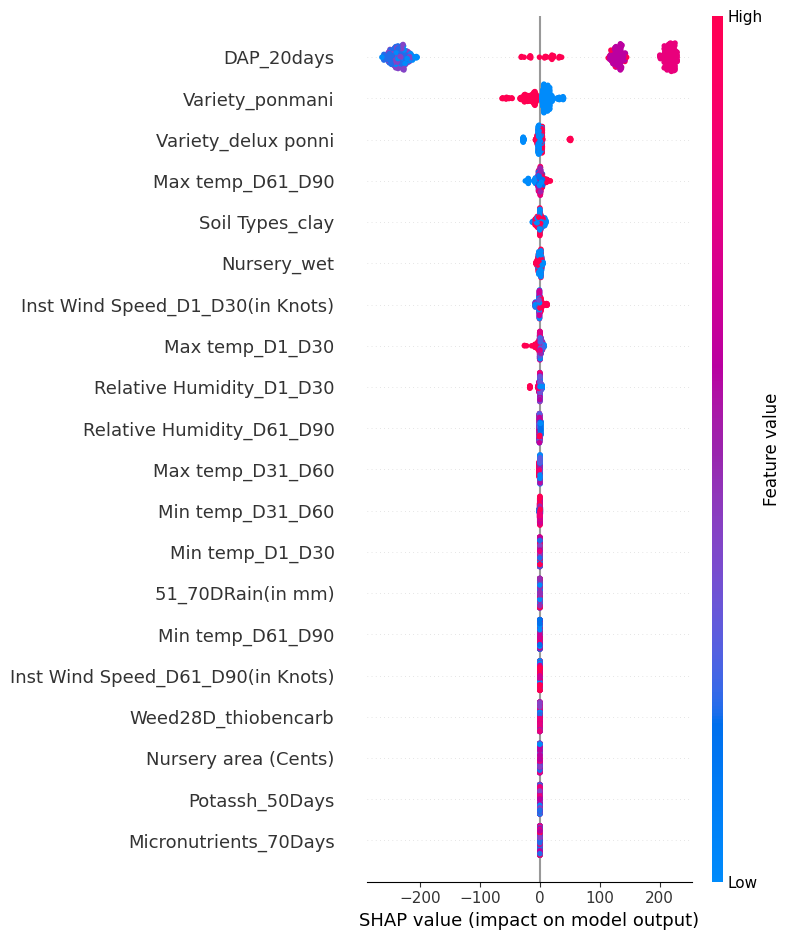

SHAP plot saved to ../shap_analysis/shap_yield_per_hectare_xgb.png


In [13]:
import shap
import matplotlib.pyplot as plt

shap_dir = Path("../shap_analysis")
shap_dir.mkdir(parents=True, exist_ok=True)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig(shap_dir / "shap_yield_per_hectare_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"SHAP plot saved to {shap_dir / 'shap_yield_per_hectare_xgb.png'}")

### SHAP Interpretation: XGBoost on Yield per Hectare

The SHAP summary plot above shows how each feature drives the XGBoost model's prediction of **paddy yield per hectare (kg/ha)**.

**Key observations:**

- **DAP_20days** (Di-Ammonium Phosphate fertiliser applied at 20 days) overwhelmingly dominates the model. Its SHAP values span a wide range, with higher DAP usage pushing predictions strongly upward. This aligns with the XGBoost feature importance where DAP accounts for ~75% of the total gain. Phosphorus is critical for root development and early crop establishment, so this finding is agronomically plausible.
- **Variety_delux ponni** and **Variety_ponmani** are the next most important features. The binary nature of these features creates two distinct clusters of SHAP values, indicating that rice variety meaningfully affects per-hectare productivity — some varieties are inherently higher yielding than others.
- **Inst Wind Speed_D1_D30 (in Knots)** and **Max temp_D61_D90** contribute modestly. Weather during early growth (wind stress) and the grain-filling stage (heat) affects yield potential, though the effects are smaller compared to fertiliser and variety.
- **Relative Humidity_D1_D30**, **Soil Types_clay**, and **Nursery_wet** have minor but non-trivial contributions. Clay soils and wet nursery conditions represent environmental baselines that the model uses to fine-tune predictions.
- The remaining features (Min temp, Max temp at other growth stages) contribute marginally.

**Takeaway:** Unlike the total-yield model (which was dominated by farm-size proxies), this per-hectare model identifies **fertiliser management (DAP)** and **variety selection** as the primary levers for improving productivity. The moderate R² (~0.51) reflects the inherent difficulty of predicting yield efficiency — many factors (pest outbreaks, microclimate variation, farmer skill) are not captured in the available features.